In [199]:
# 引入模組
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.constants import g0
from scipy.optimize import curve_fit, minimize

In [200]:
# 讀取資料
fname = './data_8.csv'
data = pd.read_csv(fname)
print(data.columns)

Index(['Length (m)', 'Duration of 10 swings (s)', 'Duration of a swing (s)',
       'Average Period of a Swing (s)', 'SD of T (s)',
       'Theoretical Value of Oscillation Period (s)', 'Error Calculation (%)'],
      dtype='str')


In [201]:
# 製作空白列表（以後當作資料儲存容器）
length_list = []
avg_period_list = []
std_list = [] # 標準差
##all_periods = []
##all_lengths = []

# 依擺長自動分組
length_groups = data.groupby('Length (m)')
for L, group in length_groups:
    
    # 只取有 SD（＆avg)的那一列（summary）
    summary = group.dropna(subset=['SD of T (s)'])
    
    if len(summary) == 0:
        continue
    
    length_list.append(L)
    avg_period＿list.append(summary['Average Period of a Swing (s)'].values[0])
    std_list.append(summary['SD of T (s)'].values[0])

這裡是最大的修正：
試錯版中，單一擺長（即單一組）的標準差都用數據檔中的Duration of a swing (s)計算，所以當前面我讓pd讀數據就順便殺掉空格時，等於只留下每一組的第一列，當然就沒有標準差樣本。
但其實數據檔中有直接給標準差，而且就在第一列，所以直接取summary可以解決問題。

In [202]:
# 轉為 numpy array
length_array = np.array(length_list)
avg_period_array = np.array(avg_period_list)
std_array = np.array(std_list)

＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝先疊個理論曲線＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝

In [203]:
# 理論曲線 （請注意這裡沒有取對數，所以是非線性ㄉ）
l_axis = np.linspace(min(length_array)*0.9, max(length_array)*1.1, 200)
t_ideal = 2 * np.pi * np.sqrt(l_axis / g0.value)

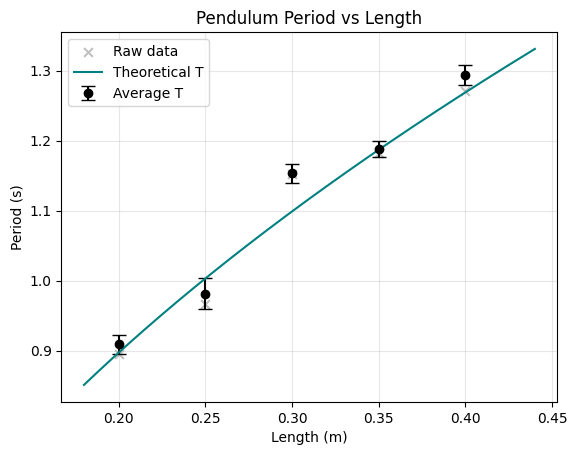

In [204]:
# 作圖！
plt.scatter(all_lengths, all_periods, 
            s=40, marker='x', color='silver',
            label='Raw data')

plt.errorbar(length_array, avg_period_array,
             yerr=std_array,
             fmt='o', color='black',
             capsize=5, label='Average T')

plt.plot(l_axis, t_ideal,
         color='teal',
         label='Theoretical T')

plt.xlabel('Length (m)')
plt.ylabel('Period (s)')
plt.title('Pendulum Period vs Length')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [205]:
# 取 ln
lnL = np.log(length_array)
lnT = np.log(avg_period_array)

# 誤差傳播：σ(lnT) = σT / T
sigma_lnT = std_array / avg_period_array

# 檢查一下數值
print("lnL =", lnL)
print("lnT =", lnT)
print("sigma_lnT =", sigma_lnT)

# 若標準差為 0，替換為所有非零誤差的平均
nonzero = sigma_lnT[sigma_lnT > 0]
sigma_lnT[sigma_lnT == 0] = np.mean(nonzero)

lnL = [-1.60943791 -1.38629436 -1.2039728  -1.04982212 -0.91629073]
lnT = [-0.09475034 -0.01857139  0.1427141   0.17260786  0.25711977]
sigma_lnT = [0.01484169 0.02261614 0.01196463 0.00950858 0.01113517]


In [206]:
def linear_function(x, a, b):
    return a * x + b

x_plot = np.linspace(min(lnL)*0.95, max(lnL)*1.05, 100)

# np.linspace: numpy 提供的一個函式，用於在指定範圍內生成等距的數值點。
# start: 起始值，這裡是 min(lnL)*0.95 (將最小值稍微縮小 5%)
# stop: 結束值，這裡是 max(lnL)*1.05 (將最大值稍微放大 5%)
# num: 生成 100 個等距的數值點
# 存入變數 x_plot 中

In [207]:
# curve fitting
popt_cf, pcov_cf = curve_fit( # scipy中的函數，用來進行非線性最小平方擬合
    linear_function,
    lnL, # x-axis
    lnT, # y-axis
    sigma=sigma_lnT, # errorbar
    absolute_sigma=True, # 確認將 sigma 視為絕對不確定
    p0=[0.5, 0.5] # 加初始值
)
# 輸出結果
a_cf, b_cf = popt_cf # 將最佳擬合參數將最佳擬合參數a和b分別儲存到變數 a_cf 和 b_cf 中

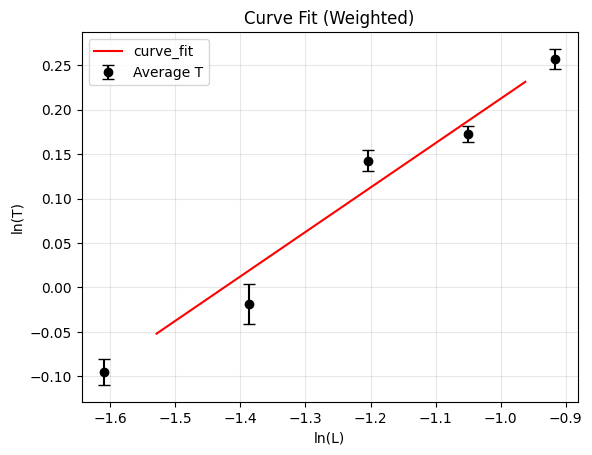

In [222]:
# 畫畫畫畫畫圖
plt.figure()
plt.errorbar(lnL, lnT, yerr=sigma_lnT, fmt='o', capsize=4, color='black', label='Average T') 
plt.plot(x_plot, linear_function(x_plot, a_cf, b_cf), color='red', label='curve_fit')
plt.title('Curve Fit (Weighted)')
plt.xlabel('ln(L)')
plt.ylabel('ln(T)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# yerr=sigma_lnT: y 軸誤差棒的長度，對應於每個資料點的標準差
# fmt='o': 資料點的樣式為圓點
# capsize=4: 誤差棒末端的橫線長度
# linear_function(x_plot, a_cf, b_cf):使用最佳擬合參數a和b計算y值

In [209]:
print("==== Curve Fit Results ====")
print(f"Curve Fit: a={a_cf:.4f}, b={b_cf:.4f}")
g_cf  = np.exp(2*(np.log(2*np.pi) - b_cf))
print("\nDerived g values:")
print(f"Curve Fit: {g_cf:.4f}")
print(f"Theoretical g  : {g0.value:.4f}")

==== Curve Fit Results ====
Curve Fit: a=0.4996, b=0.7119

Derived g values:
Curve Fit: 9.5069
Theoretical g  : 9.8066


In [210]:
# Least Squares fitting
A = np.vstack([lnL, np.ones(len(lnL))]).T
a_ls, b_ls = np.linalg.lstsq(A, lnT, rcond=None)[0]

# lnL 是一個陣列或列表，代表自變數的資料
# np.ones(len(lnL))：
# 建立一個與 lnL 長度相同的陣列，內容全為 1，這是為了代表線性迴歸中的截距項（bias）。
# np.vstack([lnL, np.ones(len(lnL))])：將 lnL 和全為 1 的陣列垂直堆疊成一個 2xN 的矩陣，其中 N 是 lnL 的長度。
# .T：將矩陣轉置，變成 Nx2 的矩陣 A，每一列包含 [lnL[i], 1]

'''
np.linalg.lstsq(A, lnT, rcond=None)：
使用最小平方法（Least Squares Method）來解線性方程式 
A⋅[a,b]=lnT，其中：
A 是上述建立的 Nx2 矩陣
lnT 是目標變數（因變數）的資料
這個函式會回傳一個包含多個結果的陣列，其中 [0] 是第一個結果，代表解出的係數 [a_ls, b_ls]。
a_ls, b_ls ：
將回傳的係數解開，分別存到變數 a_ls 和 b_ls 中。
a_ls 是斜率（slope），b_ls 是截距（intercept）。
'''

'\nnp.linalg.lstsq(A, lnT, rcond=None)：\n使用最小平方法（Least Squares Method）來解線性方程式 \nA⋅[a,b]=lnT，其中：\nA 是上述建立的 Nx2 矩陣\nlnT 是目標變數（因變數）的資料\n這個函式會回傳一個包含多個結果的陣列，其中 [0] 是第一個結果，代表解出的係數 [a_ls, b_ls]。\na_ls, b_ls ：\n將回傳的係數解開，分別存到變數 a_ls 和 b_ls 中。\na_ls 是斜率（slope），b_ls 是截距（intercept）。\n'

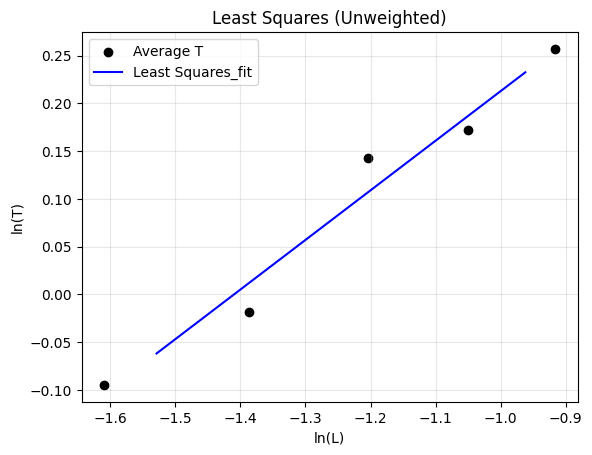

In [223]:
# 畫畫畫畫畫圖
plt.figure()
plt.scatter(lnL, lnT, color='black', label='Average T')
plt.plot(x_plot, linear_function(x_plot, a_ls, b_ls), color='blue', label='Least Squares_fit')
plt.title('Least Squares (Unweighted)')
plt.xlabel('ln(L)')
plt.ylabel('ln(T)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [212]:
print("==== Least Squares Fit Results ====")
print(f"Least Squares  : a={a_ls:.4f}, b={b_ls:.4f}")
g_ls  = np.exp(2*(np.log(2*np.pi) - b_ls))
print("\nDerived g values:")
print(f"Least Squares  : {g_ls:.4f}")
print(f"Theoretical g  : {g0.value:.4f}")

==== Least Squares Fit Results ====
Least Squares  : a=0.5194, b=0.7324

Derived g values:
Least Squares  : 9.1249
Theoretical g  : 9.8066


In [213]:
# Chi-square fitting
def chi_square(params): # params 是一個包含兩個參數的陣列 [a, b]，代表線性模型的斜率和截距
    a, b = params
    model = linear_function(lnL, a, b)
    return np.sum((lnT - model) ** 2 / sigma_lnT ** 2) # 卡方值

# 最小化卡方值
result = minimize(chi_square, x0=[0.5, 0.5], bounds=[(0,2), (-5,5)]) # x0為初始猜測值
a_chi, b_chi = result.x

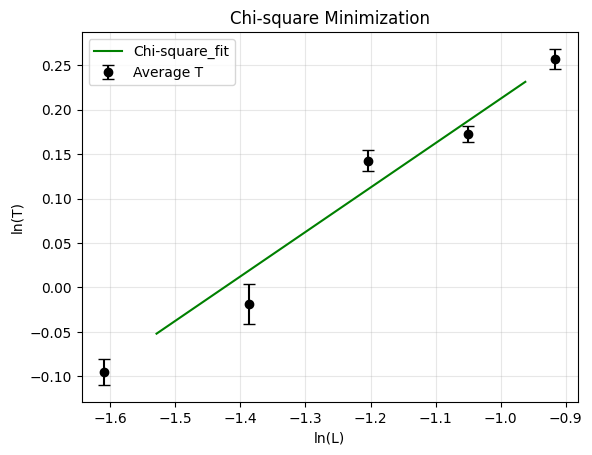

In [224]:
# 畫畫畫畫畫圖
plt.figure()
plt.errorbar(lnL, lnT, yerr=sigma_lnT, fmt='o', capsize=4, color='black', label='Average T')
plt.plot(x_plot, linear_function(x_plot, a_chi, b_chi), color='green', label='Chi-square_fit')
plt.title('Chi-square Minimization')
plt.xlabel('ln(L)')
plt.ylabel('ln(T)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [215]:
print("==== Chi-square Fit Results ====")
print(f"Chi-square Fit : a={a_chi:.4f}, b={b_chi:.4f}")
g_chi = np.exp(2*(np.log(2*np.pi) - b_chi))
print("\nDerived g values:")
print(f"Chi-square Fit : {g_chi:.4f}")
print(f"Theoretical g  : {g0.value:.4f}")

==== Chi-square Fit Results ====
Chi-square Fit : a=0.4996, b=0.7119

Derived g values:
Chi-square Fit : 9.5069
Theoretical g  : 9.8066


In [216]:
# 顯示數值比較
print("==== Fit Results ====")
print(f"Curve Fit      : a={a_cf:.4f}, b={b_cf:.4f}")
print(f"Least Squares  : a={a_ls:.4f}, b={b_ls:.4f}")
print(f"Chi-square Fit : a={a_chi:.4f}, b={b_chi:.4f}") # 格式化為小數點後四位數

==== Fit Results ====
Curve Fit      : a=0.4996, b=0.7119
Least Squares  : a=0.5194, b=0.7324
Chi-square Fit : a=0.4996, b=0.7119


In [217]:
# 由 b 反推 g
g_cf  = np.exp(2*(np.log(2*np.pi) - b_cf))
g_ls  = np.exp(2*(np.log(2*np.pi) - b_ls))
g_chi = np.exp(2*(np.log(2*np.pi) - b_chi))

print("\nDerived g values:")
print(f"Curve Fit      : {g_cf:.4f}")
print(f"Least Squares  : {g_ls:.4f}")
print(f"Chi-square Fit : {g_chi:.4f}")
print(f"Theoretical g  : {g0.value:.4f}")


Derived g values:
Curve Fit      : 9.5069
Least Squares  : 9.1249
Chi-square Fit : 9.5069
Theoretical g  : 9.8066


＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝殘差圖＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝＝

對於對數現行模型，殘差定義為
ri​=ln（Ti）​−(alnLi​+b)
而對於有errorbar的擬合，則採用加權殘差
 ri/sigma

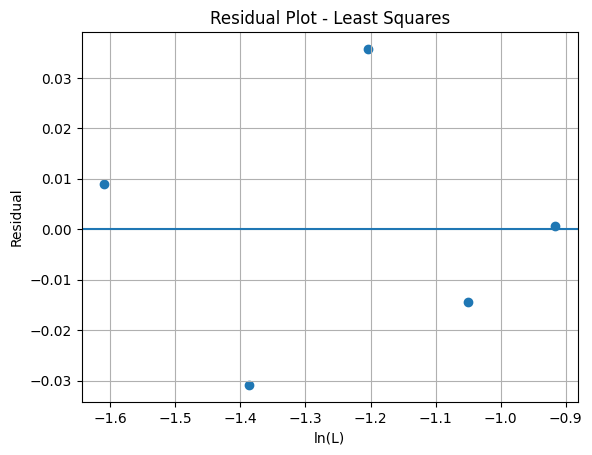

In [218]:
# Least Squares Residual 
lnT_model_ls = linear_function(lnL, a_ls, b_ls)
res_ls = lnT - lnT_model_ls

plt.figure()
plt.axhline(0)
plt.scatter(lnL, res_ls)
plt.xlabel("ln(L)")
plt.ylabel("Residual")
plt.title("Residual Plot - Least Squares")
plt.grid()
plt.show()

從上圖可以看出，Least Squares 殘差最大約 +0.035，最小約 −0.03，且有往０靠近的趨勢，表示取對數後的線性模型可能有微小非線性偏差，但幅度只有約exp 0.03≈1.03，即約 3% 偏差，非常小。

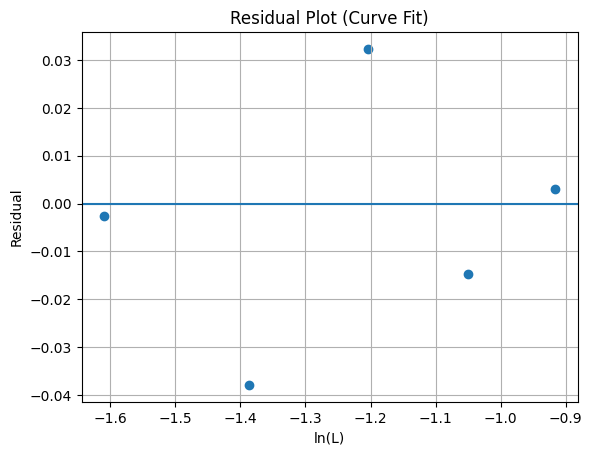

In [219]:
# curve_fit residual

# 模型預測
lnT_model = linear_function(lnL, a_cf, b_cf)

# 殘差
residuals = lnT - lnT_model

plt.figure()
plt.axhline(0)
plt.scatter(lnL, residuals)
plt.xlabel("ln(L)")
plt.ylabel("Residual")
plt.title("Residual Plot (Curve Fit)")
plt.grid()
plt.show()

由上圖可以看出，Curve Fit 殘差圖幾乎與Least Squares 殘差圖相同，表示加權前後差異並不明顯，即不存在系統性放大

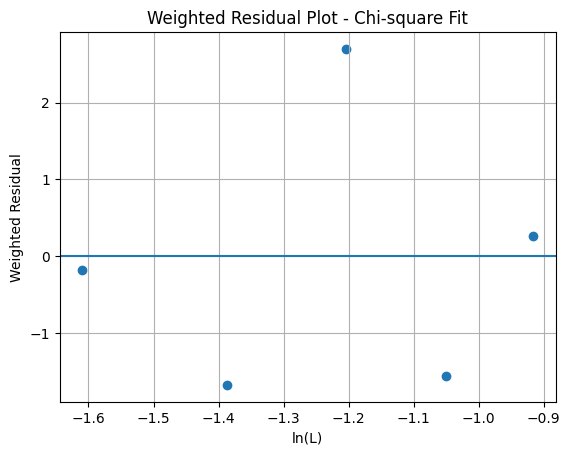

In [220]:
# Chi-square Weighted Residual
lnT_model_chi = linear_function(lnL, a_chi, b_chi)
res_chi = lnT - lnT_model_chi
weighted_res_chi = res_chi / sigma_lnT

plt.figure()
plt.axhline(0)
plt.scatter(lnL, weighted_res_chi)
plt.xlabel("ln(L)")
plt.ylabel("Weighted Residual")
plt.title("Weighted Residual Plot - Chi-square Fit")
plt.grid()
plt.show()

由上圖可知，Chi-square 加權殘差最大 ≈ +2.7，最小 ≈ −1.6，偏差幅度也是非常小，可視為無顯著非線性偏差

In [ ]:
# 檢查加權殘差數值
chi_sq = np.sum(weighted_res_chi**2)
dof = len(lnL) - 2
chi_sq_red = chi_sq / dof
print(chi_sq_red)

4.2090815456172885


Reduced chi-square = 4.21，明顯 ≫ 1
我們知道，如果模型正確、σ估計合理，卡方值應該≈ 1，卡方值等於4.21代表實際殘差約為2σ，表示誤差有被低估的可能。

總結來說，殘差圖告訴我們，殘差並未呈現曲線結構、正負交錯表示無系統性偏移，且偏差幅度也在合理範圍內，由此推測實驗結果符合理論模型。
數據誤差小於實際誤差則表示，可能有某些因素讓整體實驗數據偏離理論模型所做的預測，因此實驗數據點之間差異不大，標準差偏小，殘差卻偏大。
對於這種情況，可以找出可能存在的系統誤差，例如檢查擺角是否符合小角度近似，或是多做幾組實驗，改善隨機誤差，例如人為反應時間的誤差。